# Organizational-Capital -- a quantitative teardown
### EDGAR SG&A * perpetual inventory * annual sort * HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Premium-sign: Busted](https://img.shields.io/badge/Premium--sign-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb). We test Eisfeldt-Papanikolaou (2013): capitalize SG&A by perpetual inventory (delta=15%, steady-state seed), scale by assets, sort annually, long the high-OC half / short the low-OC half, one execution lag, HAC inference.

> **Not investment advice.** Real data: EDGAR 10-K SG&A + assets (~18-19y) and yfinance daily adjusted-close, ~39 large-cap survivors, 2009-2025, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** basket = current large-caps still trading in 2026.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from organizational_capital import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "oc_fundamentals.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "oc_prices.parquet")))

HAVE_REAL = _have_cache()
print("EDGAR + yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    fund = data.fetch_fundamentals()
    prices = data.fetch_prices()
    oc = st.org_capital_stock(fund)
    monthly = prices.resample("ME").last().pct_change().dropna(how="all")
    ls = st.long_short(oc, monthly)
    s_ls = st.summary(ls["ls"]); s_hi = st.summary(ls["high"]); s_lo = st.summary(ls["low"])
    print(f"N months: {s_ls['n']} | LS: {s_ls['mean']*100:+.2f}%/yr | HAC t: {s_ls['tstat']:+.3f}")


EDGAR + yfinance cache present: True


N months: 203 | LS: -1.68%/yr | HAC t: -0.923


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | LS **-1.68%/yr**, HAC *t* = **-0.923** (wrong sign, \|t\|<2); placebo *p* = **0.33**. |
| **Tradability** | `MIRAGE` | Net of costs **-2.28%/yr** (t=-1.25); Sharpe **-0.221**, max DD **-31.4%**. |
| **Premium-sign** | `BUSTED` | E-P predict high-OC > low-OC; here high 15.0%/yr **<** low 16.6%/yr. |

> The org-capital premium is well-documented on the broad, delisted-inclusive Compustat cross-section. On 17 years of ~39 large-cap survivors it is absent and wrong-signed -- consistent with survivorship truncating the high-risk long leg.

## 1 -- The claim, steelmanned

Build org-capital by perpetual inventory: $OC_t = (1-\delta)\,OC_{t-1} + SG\&A_t$, $\delta=0.15$, seeded at $OC_0 = SG\&A_1/(g+\delta)$. Scale: the sort variable is $OC/\text{Assets}$. Eisfeldt-Papanikolaou (2013) assert:

- **H1 (signal).** High-$OC/A$ firms earn higher average returns: $E[r^{\text{high}} - r^{\text{low}}] > 0$.
- **H2 (risk).** That premium compensates talent-mobility risk -- it is *not* mispricing.

We **reject H1** on this panel (the spread is negative and insignificant), which makes H2 moot here.

## 2 -- So what? -- the economic stakes

Capitalizing intangibles (SG&A -> org-capital, R&D -> knowledge-capital) is now standard in asset pricing (Peters-Taylor 2017). If the org-capital *return* premium does not replicate out of the discovery universe, factor models that lean on it inherit the risk.

## 3 -- The protocol

- **Fundamentals.** EDGAR 10-K annual SG&A (combined, or Selling&Marketing + G&A summed) and year-end total assets, ~18-19y per firm.
- **Org-capital.** Perpetual inventory, delta=0.15, steady-state seed (g=0.10).
- **Sort.** Annually split the basket at the median of $OC/\text{Assets}$.
- **Long-short.** Equal-weight high half minus low half; held 12 months; one execution lag.
- **Inference.** Newey-West HAC *t* on monthly long-short returns.
- **Placebo.** Shuffle $OC/\text{Assets}$ labels within each year (null).
- **Costs.** 5 bps/leg one-way at annual rebalance (100% turnover) + 50 bps/yr short borrow.
- **Universe caveat.** ~39 large-cap survivors; survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector (12-seed avg)

Sweep the planted OC premium; the long-short HAC *t*, averaged over 12 seeds, should be monotone and correctly-signed.

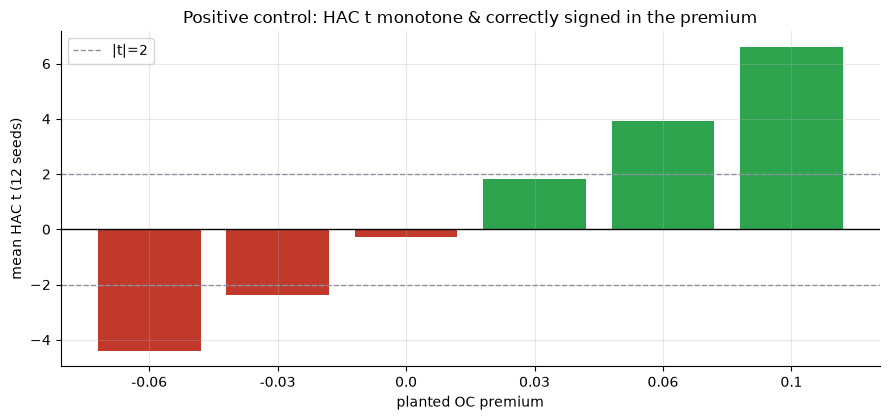

 premium  mean_ls_pct  mean_t
   -0.06      -10.169  -4.415
   -0.03       -5.383  -2.363
    0.00       -0.596  -0.270
    0.03        4.190   1.834
    0.06        8.976   3.918
    0.10       15.358   6.616


In [2]:
ctrl = st.synthetic_control()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['mean_t']]
ax.bar(ctrl['premium'].astype(str), ctrl['mean_t'], color=col)
ax.axhline(0, c='k', lw=1); ax.axhline(2, c=GREY, ls='--', lw=1, label='|t|=2')
ax.axhline(-2, c=GREY, ls='--', lw=1)
ax.set_xlabel('planted OC premium'); ax.set_ylabel('mean HAC t (12 seeds)')
ax.set_title('Positive control: HAC t monotone & correctly signed in the premium')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

### 4b -- The org-capital cross-section on the real tape

What does $OC/\text{Assets}$ look like across the basket in the latest year?

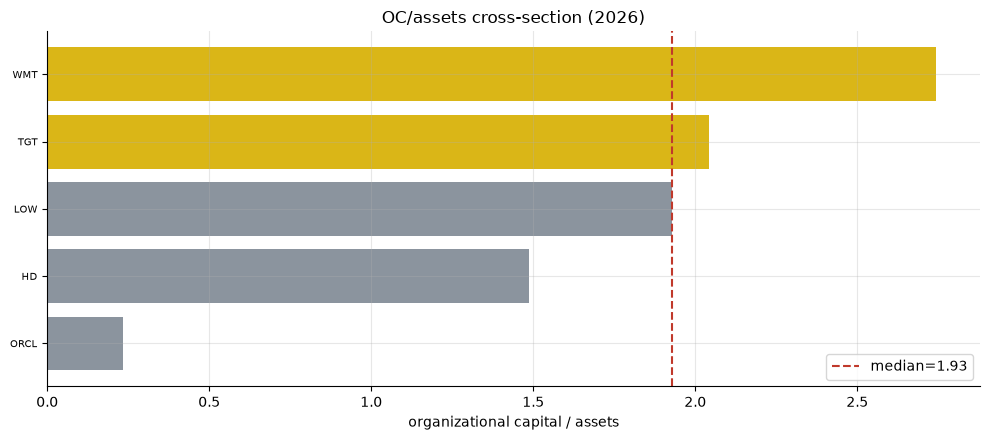

High-OC (amber) = long leg, low-OC (grey) = short leg. n=5


In [3]:
if HAVE_REAL:
    last_y = oc['fyear'].max()
    snap = oc[oc['fyear'] == last_y].set_index('ticker')['oc_assets'].sort_values()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    colors = [GREY if v <= snap.median() else AMBER for v in snap.values]
    ax.barh(snap.index, snap.values, color=colors)
    ax.axvline(snap.median(), c=RED, ls='--', lw=1.5, label=f'median={snap.median():.2f}')
    ax.set_xlabel('organizational capital / assets'); ax.set_title(f'OC/assets cross-section ({last_y})')
    ax.legend(); ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout(); plt.show()
    print(f'High-OC (amber) = long leg, low-OC (grey) = short leg. n={len(snap)}')
else:
    print('Cross-section requires the real cache.')

### 4c -- Real long-short: returns, legs, equity curve

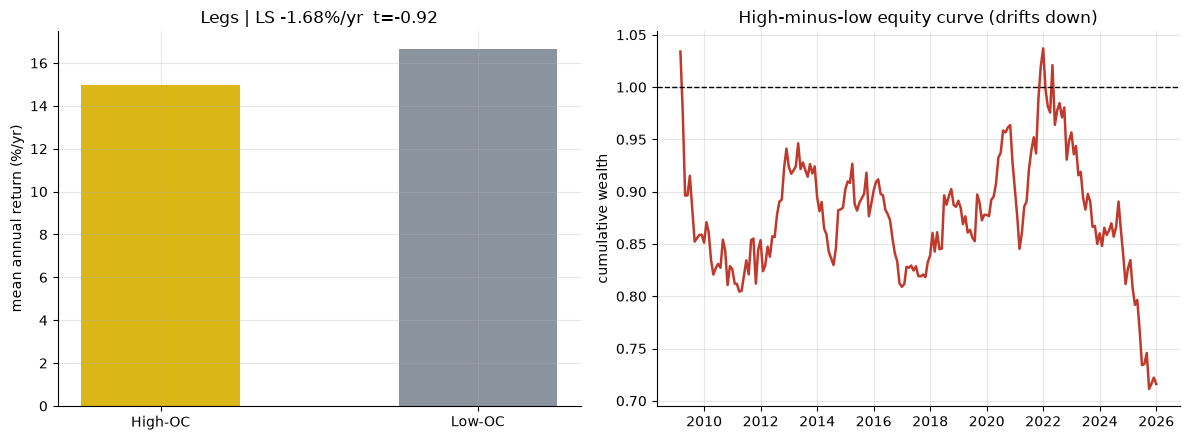

LS -1.68%/yr | HAC t -0.923 | high 14.96% vs low 16.65%


In [4]:
if HAVE_REAL:
    lsm, lst = s_ls['mean']*100, s_ls['tstat']
    hi, lo = s_hi['mean']*100, s_lo['mean']*100
    eq = (1 + ls['ls']).cumprod(); dd = (eq/eq.cummax()-1)*100
else:
    lsm, lst, hi, lo = R['ls_gross'], R['ls_t'], R['high_leg'], R['low_leg']
    eq = pd.Series(dtype=float); dd = pd.Series(dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['High-OC', 'Low-OC'], [hi, lo], color=[AMBER, GREY], width=.5)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title(f'Legs | LS {lsm:+.2f}%/yr  t={lst:+.2f}')
if HAVE_REAL:
    axes[1].plot(eq.index, eq.values, c=RED, lw=1.8)
    axes[1].axhline(1, c='k', lw=1, ls='--')
    axes[1].set_title('High-minus-low equity curve (drifts down)')
    axes[1].set_ylabel('cumulative wealth')
else:
    axes[1].text(.5, .5, 'real cache needed', ha='center')
plt.tight_layout(); plt.show()
print(f'LS {lsm:+.2f}%/yr | HAC t {lst:+.3f} | high {hi:.2f}% vs low {lo:.2f}%')

### 4d -- Placebo: shuffle the org-capital labels within each year

If the OC ranking carried real information, the true long-short would sit in the tail of the label-shuffled null. It does not.

In [5]:
if HAVE_REAL:
    pb = st.placebo_pvalue(oc, monthly, n_shuffles=400)
    real_mo = pb['real_mean']*100
    print(f"placebo p = {pb['p_value']:.3f}  (real {real_mo:+.4f}%/mo vs "
          f"null {pb['null_mean']*100:+.4f}% +/- {pb['null_std']*100:.4f}%, n={pb['n_shuffles']})")
    p = pb['p_value']
else:
    p = R['placebo_p']; real_mo = R['placebo_real']*100
    print(f'Frozen placebo p = {p:.3f}')
print('p >= 0.05 -> the real long-short is indistinguishable from a shuffled-label null.')

placebo p = 0.335  (real -0.1403%/mo vs null +0.0148% +/- 0.1385%, n=400)
p >= 0.05 -> the real long-short is indistinguishable from a shuffled-label null.


### 4e -- Robustness: does the depreciation rate change the verdict?

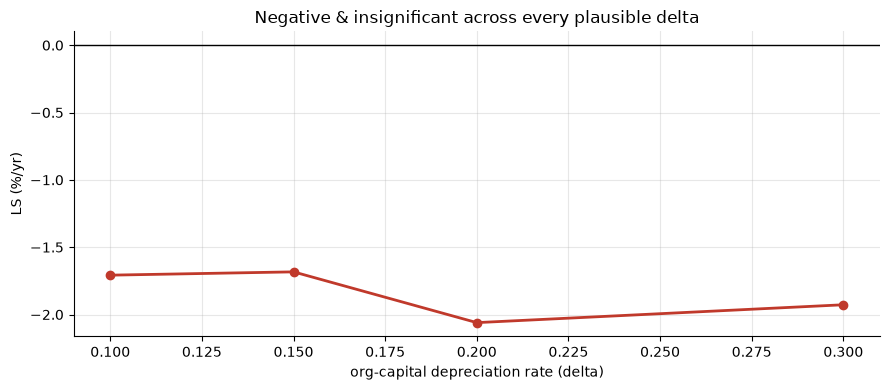

 delta  LS_%/yr  HAC_t
  0.10   -1.708 -0.920
  0.15   -1.683 -0.923
  0.20   -2.060 -1.130
  0.30   -1.928 -1.051


In [6]:
if HAVE_REAL:
    rows = []
    for d in (0.10, 0.15, 0.20, 0.30):
        s_d = st.summary(st.long_short(st.org_capital_stock(fund, delta=d), monthly)['ls'])
        rows.append({'delta': d, 'LS_%/yr': s_d['mean']*100, 'HAC_t': s_d['tstat']})
    sweep = pd.DataFrame(rows)
else:
    sweep = pd.DataFrame([{'delta': d, 'LS_%/yr': v[0], 'HAC_t': v[1]}
                          for d, v in R['delta_sweep'].items()])
fig, ax = plt.subplots(figsize=(9, 4.0))
ax.plot(sweep['delta'], sweep['LS_%/yr'], 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('org-capital depreciation rate (delta)'); ax.set_ylabel('LS (%/yr)')
ax.set_title('Negative & insignificant across every plausible delta')
plt.tight_layout(); plt.show()
print(sweep.round(3).to_string(index=False))

## 5 -- The verdict

- **Signal `NONE`** -- LS -1.68%/yr, HAC *t* = -0.923 (wrong sign, \|t\|<2), placebo *p* = 0.33, negative across every delta. No literature upgrade: the published premium lives on a delisted-inclusive universe we cannot reproduce here, and the *sign itself* fails.
- **Tradability `MIRAGE`** -- net -2.28%/yr, Sharpe -0.221, max DD -31.4%. Nothing to trade.
- **Premium-sign `BUSTED`** -- the synthetic control recovers the planted, correctly-signed premium, so the real-tape sign flip is the market (and the survivor truncation), not the engine.

## 6 -- Could you trade it?

No. The spread is negative gross and net; the borrow on the short leg and the annual rebalance turnover only add cost. The deeper problem is structural: the risk story puts the premium on firms that *might fail by losing their talent* -- and those firms are exactly the ones a current-large-cap basket deletes.

## 7 -- Going further

- **Delisted-inclusive Compustat panel** -- the only honest replication of the original.
- **Within-industry sort** -- strip out the consumer-staples-vs-software SG&A gap.
- **Value-weight & microcaps** -- where Hou-Xue-Zhang (2020) find most anomalies live or die.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)** / **[Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**: same desk machinery on adjacent risk-premium claims.

*Think org-capital pays once survivorship and industry are fixed? Fork this, add the delisted tail, and show t > 2 with the right sign net of costs. That is the bar.*